<a href="https://colab.research.google.com/github/tasveebyousaf/montecarlo-equity-simulator/blob/main/montecarlo_equity_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting price : $358.96
Expected price : $390.31
Std deviation  : $93.88
95% VaR floor  : $258.08
Prob(profit)   : 59.70%


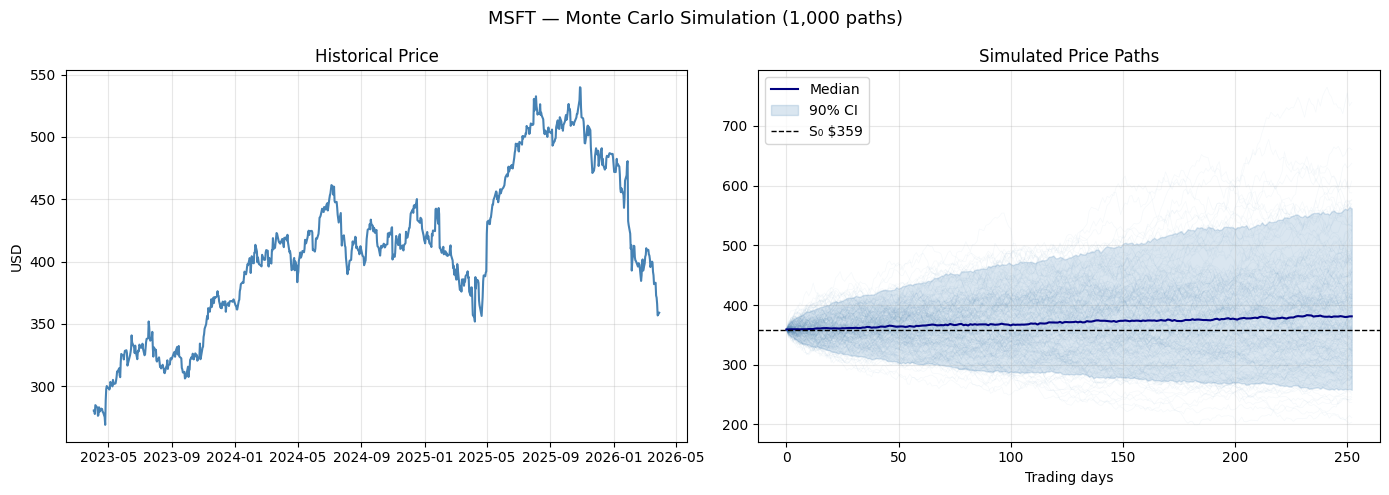

In [2]:
# Monte Carlo Stock Price Simulation — MSFT
# Uses Geometric Brownian Motion (GBM) to simulate future prices

!pip install yfinance matplotlib numpy pandas --quiet

import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta

# ── Parameters ────────────────────────────────────────────────────────────────
TICKER     = "MSFT"
HIST_YEARS = 3
N_SIMS     = 1000
N_DAYS     = 252   # ~1 trading year

np.random.seed(42)

# ── Download historical data ──────────────────────────────────────────────────
start = (datetime.today() - timedelta(days=365 * HIST_YEARS)).strftime("%Y-%m-%d")
prices = yf.download(TICKER, start=start, progress=False)["Close"].dropna()
S0 = float(prices.iloc[-1])

# ── Calibrate GBM parameters from log-returns ────────────────────────────────
log_returns = np.log(prices / prices.shift(1)).dropna()
mu    = float(log_returns.mean())   # daily drift
sigma = float(log_returns.std())    # daily volatility

# ── Simulate price paths ──────────────────────────────────────────────────────
# GBM exact form: S(t) = S(0) * exp((mu - 0.5*sigma^2)*t + sigma*W(t))
Z = np.random.standard_normal((N_DAYS, N_SIMS))
daily_log_returns = (mu - 0.5 * sigma**2) + sigma * Z
price_paths = S0 * np.exp(np.cumsum(daily_log_returns, axis=0))
price_paths = np.vstack([np.full(N_SIMS, S0), price_paths])  # prepend starting price

# ── Print metrics ─────────────────────────────────────────────────────────────
final = price_paths[-1]
print(f"Starting price : ${S0:,.2f}")
print(f"Expected price : ${final.mean():,.2f}")
print(f"Std deviation  : ${final.std():,.2f}")
print(f"95% VaR floor  : ${np.percentile(final, 5):,.2f}")
print(f"Prob(profit)   : {np.mean(final > S0):.2%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"{TICKER} — Monte Carlo Simulation ({N_SIMS:,} paths)", fontsize=13)

# Left: historical prices
ax1.plot(prices.index, prices.values, color="steelblue", linewidth=1.5)
ax1.set_title("Historical Price")
ax1.set_ylabel("USD")
ax1.grid(alpha=0.3)

# Right: simulated paths
days = np.arange(N_DAYS + 1)
for i in np.random.choice(N_SIMS, 200, replace=False):
    ax2.plot(days, price_paths[:, i], alpha=0.05, linewidth=0.5, color="steelblue")
ax2.plot(days, np.median(price_paths, axis=1), color="navy", linewidth=1.5, label="Median")
ax2.fill_between(days,
                 np.percentile(price_paths, 5, axis=1),
                 np.percentile(price_paths, 95, axis=1),
                 alpha=0.2, color="steelblue", label="90% CI")
ax2.axhline(S0, color="black", linestyle="--", linewidth=1, label=f"S₀ ${S0:,.0f}")
ax2.set_title("Simulated Price Paths")
ax2.set_xlabel("Trading days")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("monte_carlo_msft.png", dpi=150, bbox_inches="tight")
plt.show()